#  Film Industry Analysis for Business Expansion 

##  **Introduction**  
As part of a company's expansion into the entertainment industry, they are exploring the creation of a new movie studio. However, with no prior experience in film production, it is critical to make data-driven decisions about the types of movies to develop.  

In this project, I will analyze movie industry data to answer key business questions:  
- *Which movie genres tend to receive the highest ratings?* 
- *Which genres have the highest return on investment (ROI)?*
- *Are certain directors more likely to deliver high foreign box office success?*  
- *Which film languages are associated with higher popularity?*  

The goal is to uncover patterns and insights that will help guide the company's decisions on what types of films to produce for maximum commercial success.


## 【1】**Data Exploration**  

### *Loading Datasets*
It is crucial we thoroughly explore each of our datasets and database tables. The datasets we are working with include:
- `Box Office Mojo`
- `IMDB`
- `Rotten Tomatoes Movies`
- `Rotten Tomatoes Critic Reviews`
- `TheMovieDB`
- `The Numbers`
- `im.db` (SQLite database)

Data exploration helps us understand the structure, quality, and characteristics of the data we are working with.  
By examining distributions, missing values, duplicates, and relationships between variables, we can identify potential issues early and plan our cleaning and transformation strategies more effectively.  
This step ensures that our later analyses are based on a solid understanding of the data, reducing the risk of errors and unexpected results.



In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Establish a connection to the database
conn = sqlite3.connect('Data/im.db')

# Check available tables (optional, good for understanding structure)
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)


,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [3]:
# Close connection
conn.close()

Load all Datasets into Pandas Dataframes:

In [4]:
bom_df = pd.read_csv('Data/bom.movie_gross.csv')
bom_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [5]:
rt_rev_df = pd.read_csv('Data/rt_critic_reviews.csv')
rt_rev_df.head()

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...


In [6]:
rt_df = pd.read_csv('Data/rt_movies.csv')
rt_df.head()

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3


In [7]:
tmdb_df = pd.read_csv('Data/tmdb.movies.csv')
tmdb_df.head()

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


In [8]:
tn_df = pd.read_csv('Data/tn.movie_budgets.csv')
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


After successfully loading all the datasets using pandas, we are now ready to dive deeper into data exploration. Given that we are working with six distinct datasets and a database, manually using `.info()`, `.describe()`, `.isna()`, and writing separate code blocks to inspect every dataframe would be highly inefficient, tedious and extremely confusing. Moreover, for the `im.db` database, exploring each table one by one through traditional code would have required an overwhelming amount of setup, making the process unnecessarily complex.

To overcome this, we identified tools that allowed us to explore our data in a far more efficient and highly visual manner.  


### *Data Exploration with Data Wrangler and SQLite Viewer*

For the initial exploration of our datasets, we utilized two powerful Visual Studio Code extensions: 

`Data Wrangler` made early-stage data exploration much faster and more intuitive by providing:
- Visual summaries of column distributions and data types.
- Instant detection of missing values, outliers, and duplicates.
- Quick sorting, filtering, and grouping operations without needing to write code.
- Profiling of datasets with automated suggestions for cleaning and transformation.

`SQLite Viewer` allowed us to efficiently browse the database structure and contents without having to write extensive SQL queries.  
With it, we could:
- Instantly preview tables, columns, and sample data.
- Navigate between tables and their relationships quickly.
- Understand data volumes, missing values, and schema designs in a highly visual and interactive way.

Using `Data Wrangler` and `SQLite Viewer` streamlined our workflow significantly.  
Instead of manually traversing large datasets and databases line-by-line in code, we were able to focus our time on identifying meaningful issues, relationships, and insights

<div style="white-space: nowrap; overflow-x: auto;">
    <img src="images/bom_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/rt_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/rt_rev_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/tmdb_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/tn_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/im.db.png" style="display: inline-block; height: 500px; margin-right: 10px;">
</div>

After thorough exploration and exhaustive discussion of the datasets, we carefully evaluated the available columns. Based on importance to our project goals and quality, we decided on a final set of columns that would be most effective for a meaningful analysis:

- From `rotten_tomatoes`:
  - `movie_title`, `genres`, `tomatometer_rating`, `audience_rating`  
    → These columns help us evaluate which movie genres tend to receive the highest critical and audience ratings.

- From `tmdb`:
  - `language`, `popularity`  
    → These attributes allow us to investigate how a film's language impacts its popularity and, by extension, potential profitability.

- From `the_numbers`:
  - `movie`, `production_budget`, `worldwide_gross`  
    → These financial figures are crucial for calculating Return on Investment (ROI) and understanding broader profitability patterns across genres.

- From `im.db`:
  - Extracting and joining data across the `directors`, `persons`, and `movie_akas` tables  
    → This allows us to match each director with the correct movie title, enabling the analysis of which directors tend to deliver high foreign box office success.

Our data exploration confirmed that the columns we selected had either zero or extremely low missing values and were populated with a wide range of distinct entries, indicating that the data quality was high and free from placeholder values.
Even though these are the specific columns we are interested in, it is still necessary to properly prepare and relate the data across different datasets to build a strong foundation for answering the business questions effectively.  


### Key Notes

- **Replacement of Rotten Tomatoes Dataset:**  
  We did not use the originally provided Rotten Tomatoes datasets, as they were inadequate for our analysis.  
  The main relationship between all datasets is the `movie title`, and the provided Rotten Tomatoes tables were missing the movie title column entirely.  
  To ensure consistency and completeness, we imported a more reliable Rotten Tomatoes dataset from [Kaggle](https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset?select=rotten_tomatoes_movies.csv).

- **Exclusion of Box Office Mojo and Rotten Tomatoes Critic Reviews:**  
  We decided not to use the Box Office Mojo dataset because its information overlapped significantly with The Numbers dataset, which had more complete and reliable financial data.  
  Similarly, the Rotten Tomatoes Critic Reviews dataset was not utilized, as the Rotten Tomatoes Movies Info dataset already provided all the necessary critical and audience rating information for our needs.


## 【2】**Data Preparation & Cleaning**  

Before conducting meaningful analysis, it is essential to properly prepare and clean the data. Even though our data exploration confirmed that we are working with high-quality datasets. Since our datasets come from a variety of origins. Preparation involves filtering relevant columns, renaming fields for consistency, handling duplications, and merging datasets where necessary.  

### **Preparing Rotten Tomatoes Ratings and Genres Data**

To explore the relationship between movie genres, ratings, and their potential connection to success,  
we will prepare and clean the `Rotten Tomatoes Movies` dataset. This dataset provides detailed metadata for a wide range of movies collected from the Rotten Tomatoes website, including information that will be essential for answering our business questions regarding audience perception and genre trends.

#### *Extracting Ratings and Genres Data*

We focus on extracting four key columns from the dataset, which are essential for analyzing movie success and audience perception. The columns we are interested in are:

- `movie_title`: The title of the movie as listed on Rotten Tomatoes.
- `genres`: A comma-separated list of genres assigned to each movie (e.g., Drama, Comedy, Action).
- `audience_rating` The average rating given by the audience, typically scored from 0 to 100.
- `tomatometer_rating` The percentage of positive critic reviews.

When preparing this data, we must be mindful of movies being associated with multiple genres, which requires careful parsing to ensure accurate representation. 

In [9]:
# Extracting the relevant columns
df_rt = rt_df[["movie_title","genres","audience_rating","tomatometer_rating"]].copy()

# Convert the comma-separated string into a list
df_rt['genres'] = df_rt['genres'].str.split(', ')

# Exploding the genres
rt_movies_exploded = df_rt.explode('genres').reset_index(drop=True)
rt_movies_exploded.head()

,movie_title,genres,audience_rating,tomatometer_rating
0,Percy Jackson & the Olympians: The Lightning T...,Action & Adventure,53.0,49.0
1,Percy Jackson & the Olympians: The Lightning T...,Comedy,53.0,49.0
2,Percy Jackson & the Olympians: The Lightning T...,Drama,53.0,49.0
3,Percy Jackson & the Olympians: The Lightning T...,Science Fiction & Fantasy,53.0,49.0
4,Please Give,Comedy,64.0,87.0


We **explode** the `genres` column so that each genre becomes a separate row. This transformation turns one-to-many relationships into one-to-one, making it easier to analyze the data by individual genre. After exploding the column, we should reset the index to clean up the DataFrame and ensure the data is well-organized.



In [10]:
# Comparing the number of rows for main df and the exploded df 
print(f"main: {rt_df.shape[0]} rows")
print(f"exploded: {rt_movies_exploded.shape[0]} rows")


main: 17712 rows
exploded: 39388 rows


Comparing the number of rows in the original DataFrame with the number of rows in the exploded DataFrame helps us confirm that multiple genres per movie were successfully separated into individual rows. An increase in the number of rows indicates that the transformation was successful.

In [11]:
# Seeing if the number of unique movie_title values matches with the main
print(f"exploded: {len(rt_movies_exploded['movie_title'].unique())} unique values")
print(f"main df: {len(rt_df['movie_title'].unique())} unique values")


exploded: 17106 unique values
main df: 17106 unique values


We verify that the number of unique `movie_title` entries remain consistent between the original and exploded datasets. This confirms that the process of exploding the genres did not result in any accidental duplication or loss of movies.


#### *Data Cleaning*

From our earlier data exploration, we confirmed that the columns we are focusing on - `genres`, `audience_rating`, and `tomatometer_rating` contain no duplicates or placeholders. Each column has distinct values, ensuring the data is well-structured. However, we also observed that there are between 0% to 1% of missing values in these columns. Since these missing values are minimal, we can handle them appropriately without significantly affecting the accuracy of our cleaned dataset. In this case, dropping these rows will not reduce the dataset's integrity.

In [12]:
# Checking if missing values align with data exploration findings
(rt_movies_exploded.isna().sum()/len(rt_movies_exploded)*100)

movie_title           0.000000
genres                0.048238
audience_rating       1.241495
tomatometer_rating    0.233574
dtype: float64

Our check confirms that the missing values align with our previous findings. We can now proceed with dropping the rows containing missing values.

In [13]:
# Dropping rows with missing values under 'genres', 'audience_rating', and 'tomatometer_rating'
rt_movies_exploded_cleaned = (
    rt_movies_exploded
    .dropna(subset=["genres", "audience_rating", "tomatometer_rating"])
    .reset_index(drop=True)
)

# Checking if there are any missing values left
rt_movies_exploded_cleaned.isna().sum()


movie_title           0
genres                0
audience_rating       0
tomatometer_rating    0
dtype: int64

#### *Checking for Outliers*

Outliers can skew our analysis and lead to inaccurate results. Identifying and handling them ensures the data better reflects overall trends.

We will use the Interquartile Range (IQR) method to check for outliers:
- **IQR = Q3 - Q1**
- Any data point below **Q1 - 1.5 * IQR** or above **Q3 + 1.5 * IQR** is considered an outlier.

We will apply this logic to `audience_rating` and `tomatometer_rating`



In [14]:
# Checking for outliers
def check_outliers(q1,q3,min,max):
    iqr=q3-q1
    upper_bound=q3+(1.5*iqr)
    lower_bound=q1-(1.5*iqr)
    if (min>lower_bound) & (max<upper_bound):
     return("There are no outliers")
    else:
     return("There are outliers")
 
# Checking in the audience_rating column
print(f"{check_outliers(q1=46,q3=78,min=0,max=100)} in the audience rating column")

# Checking in the tomatometer_rating column
print(f"{check_outliers(q1=40,q3=86,min=0,max=100)} in the tomatometer rating column")


There are no outliers in the audience rating column
There are no outliers in the tomatometer rating column


#### *Standardizing text columns*
Standardization helps avoid inconsistencies during grouping, searching, or filtering. (e.g., "Drama" and "drama" would otherwise be treated differently). We standardize text data by converting `movie_title` and `genres` columns to lowercase.


In [15]:
# Making sure to work on a copy to avoid the SettingWithCopyWarning
rt_movies_exploded_cleaned = rt_movies_exploded_cleaned.copy()

# Standardizing columns to lowercase
rt_movies_exploded_cleaned["genres"] = rt_movies_exploded_cleaned["genres"].str.lower()
rt_movies_exploded_cleaned["movie_title"] = rt_movies_exploded_cleaned["movie_title"].str.lower()

rt_movies_exploded_cleaned.head()

,movie_title,genres,audience_rating,tomatometer_rating
0,percy jackson & the olympians: the lightning t...,action & adventure,53.0,49.0
1,percy jackson & the olympians: the lightning t...,comedy,53.0,49.0
2,percy jackson & the olympians: the lightning t...,drama,53.0,49.0
3,percy jackson & the olympians: the lightning t...,science fiction & fantasy,53.0,49.0
4,please give,comedy,64.0,87.0


#### *Aggregating Ratings by Genre*

To better understand how different genres perform on average with audiences and critics, we grouped the cleaned dataframe by genre and calculated the mean of both the audience ratings and the tomatometer ratings. This aggregation helps us identify broader trends and preferences across movie genres, rather than focusing on individual movie performances.


In [16]:
# Grouping by genres and aggregating the mean of audience_rating and tomatometer_rating
genre_rating_df = rt_movies_exploded_cleaned.groupby('genres').agg({
    'audience_rating': 'mean',
    'tomatometer_rating': 'mean'
}).reset_index()

# Formatting the ratings to show only one decimal place
genre_rating_df['audience_rating'] = genre_rating_df['audience_rating'].round(1)
genre_rating_df['tomatometer_rating'] = genre_rating_df['tomatometer_rating'].round(1)

genre_rating_df


,genres,audience_rating,tomatometer_rating
0,action & adventure,57.9,54.2
1,animation,65.7,64.1
2,anime & manga,75.0,75.4
3,art house & international,66.5,71.0
4,classics,71.0,78.4
5,comedy,58.4,55.1
6,cult movies,55.8,60.5
7,documentary,73.3,80.9
8,drama,63.1,63.2
9,faith & spirituality,70.3,63.9


In [17]:
# Confirming no genres were lost after aggregation
len(rt_movies_exploded_cleaned['genres'].value_counts()) == len(genre_rating_df)

True

### **Preparing Genres and ROI Data** 

In this section, we will focus on preparing two key components: **genres** and **Return on Investment (ROI)**. Both are essential for understanding the financial success and audience preferences of movies.

We will use:
- `tn.movie_budgets`: This table contains information on the `Production Budget`, `Worldwide Gross`, and the engineered `ROI` column.
- `rt_movies`: This table provides the `Genres` associated with each movie.

**Genres** provide valuable insight into the themes and categories that resonate most with audiences, while **ROI** helps us assess the profitability of each movie relative to its production cost. By calculating and analyzing ROI alongside genres, we can identify which genres are the most profitable and thus prioritize them for future movie production.




#### *Merging Appropriate Tables*

We will merge the `tn.movie_budgets` dataset (which contains production budgets and worldwide gross revenue) with the `rt_movies` dataset (which includes genre information). The key idea is to join these datasets on the **movie title** to create a consolidated table that includes both **genres** and **ROI** for each movie.

In [18]:
# Prepare movie titles for better matching (remove special characters, lower case)
tn_df['movie'] = tn_df['movie'].str.strip().str.lower()
rt_df['movie_title'] = rt_df['movie_title'].str.strip().str.lower()

# Merge the datasets on the appropriate columns
merged_df = tn_df.merge(rt_df[['movie_title', 'genres']], left_on='movie', right_on='movie_title', how='left')

# Drop duplicate movie_title column if you want
merged_df = merged_df.drop(columns=['movie_title'])

merged_df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres
0,1,"Dec 18, 2009",avatar,"$425,000,000","$760,507,625","$2,776,345,279","Action & Adventure, Comedy, Mystery & Suspense..."
1,2,"May 20, 2011",pirates of the caribbean: on stranger tides,"$410,600,000","$241,063,875","$1,045,663,875","Action & Adventure, Comedy, Science Fiction & ..."
2,3,"Jun 7, 2019",dark phoenix,"$350,000,000","$42,762,350","$149,762,350","Action & Adventure, Drama, Science Fiction & F..."
3,4,"May 1, 2015",avengers: age of ultron,"$330,600,000","$459,005,868","$1,403,013,963","Action & Adventure, Science Fiction & Fantasy"
4,5,"Dec 15, 2017",star wars ep. viii: the last jedi,"$317,000,000","$620,181,382","$1,316,721,747",NaN


#### *ROI Computation*

In this step, we aim to calculate the **Return on Investment (ROI)** for each movie. ROI is a key financial metric that helps us assess the profitability of a film relative to its production cost. By calculating the ROI for each movie, we can better understand which films have been the most financially successful and use that insight to inform future production decisions.

The calculation of ROI will be based on the formula:

**ROI = (Worldwide Gross - Production Budget) ÷ Production Budget × 100**


In [19]:
# Clean up the dollar signs and commas and convert columns to numeric
merged_df['production_budget'] = merged_df['production_budget'].replace([r'[\$,]'], '', regex=True).astype(float)
merged_df['worldwide_gross'] = merged_df['worldwide_gross'].replace([r'[\$,]'], '', regex=True).astype(float)

# Calculate ROI
merged_df['ROI (%)'] = ((merged_df['worldwide_gross'] - merged_df['production_budget']) / merged_df['production_budget']) * 100

# Round ROI to nearest whole number
merged_df['ROI (%)'] = merged_df['ROI (%)'].round()

# Group by 'movie' and calculate the mean ROI (though each movie is unique here)
roi_grouped = merged_df.groupby('movie')[['ROI (%)']].mean().reset_index()

# Final table: Comparison between genres and the grouped movie ROI
final_table = merged_df[['genres', 'movie']].merge(roi_grouped, on='movie')

final_table.isna().sum()

genres     1264
movie         0
ROI (%)       0
dtype: int64

#### Handling Missing Values 

In [20]:
final_table.isna().sum()

genres     1264
movie         0
ROI (%)       0
dtype: int64

Since the `genres` column has 1264 missing values and is crucial for our analysis, we will drop these rows as they do not provide useful information for our objectives.

In [21]:
final_table.dropna(subset=['genres'], inplace=True)

#### *Expanding Movies into Individual Genres*

We aim to break down each movie's genre information to better understand how individual genres contribute to a movie's success. Since movies can belong to multiple genres, expanding the dataset to reflect each genre individually will allow us to analyze the performance of each genre separately.

By doing so, we can identify which genres tend to perform better financially and make more informed decisions about which genres to prioritize in future film productions.


In [22]:
# Split genres into a list
final_table['genres'] = final_table['genres'].str.split(',')

# Explode the list into separate rows
exploded_table = final_table.explode('genres')

# Remove extra spaces around genre names
exploded_table['genres'] = exploded_table['genres'].str.strip()

exploded_table


,genres,movie,ROI (%)
0,Action & Adventure,avatar,553.0
0,Comedy,avatar,553.0
0,Mystery & Suspense,avatar,553.0
0,Science Fiction & Fantasy,avatar,553.0
1,Action & Adventure,pirates of the caribbean: on stranger tides,155.0
...,...,...,...
6223,Mystery & Suspense,following,3908.0
6226,Comedy,my date with drew,16358.0
6226,Documentary,my date with drew,16358.0
6226,Special Interest,my date with drew,16358.0


#### *Cleaning and Grouping by Genres*

We aim to clean the data and group the movies by their genres to calculate the average Return on Investment (ROI) for each genre. Cleaning the data ensures that we remove any rows with missing or invalid information, which could distort our analysis. Sorting the data by ROI will help us identify the top-performing genres, providing valuable information for future movie production decisions.


In [23]:
# Drop rows with NULLs in important columns
exploded_table = exploded_table.dropna(subset=['genres', 'movie', 'ROI (%)'])

# Group by 'genres' and calculate average ROI
grouped_table = exploded_table.groupby('genres')['ROI (%)'].mean().reset_index()

# Sort by ROI in descending order
grouped_table = grouped_table.sort_values(by='ROI (%)', ascending=False)

# Reset index to clean it up
grouped_table = grouped_table.reset_index(drop=True)

grouped_table.head()

,genres,ROI (%)
0,Cult Movies,4669.958333
1,Horror,975.298217
2,Special Interest,932.209677
3,Documentary,868.586466
4,Classics,839.873684


### **Preparing Language and Popularity Data**

To support the company's goal of identifying the most successful types of films at the box office, we begin by analyzing two key variables from *The Movie DB* dataset: `original_language` and `popularity`. The `original_language` column helps us understand which linguistic markets (e.g., English, Spanish, etc.) dominate box office performance, guiding strategic decisions about which language(s) to prioritize in production—either to reach the broadest audience or to tap into emerging markets. The `popularity` column serves as a proxy for viewer engagement and interest, offering insight into which films generate buzz and traction among audiences. By examining both these variables, we can uncover patterns between language, popularity, and potential box office success. 

Before diving into the data preparation, let’s quickly glance at the first few rows of the dataset to visually remind ourselves of what we’re working with.

In [24]:
tmdb_df.head(5)

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


During the data exploration phase, we utilized the Data Wrangler tool to inspect the columns of interest: `original_language` and `popularity`. Thanks to this thorough exploration, we confirmed that both columns had no missing values, ensuring that our analysis would proceed without any gaps in the data.


#### *Handling Outliers in Popularity Scores*

Before extracting the relevant columns for analysis, it's important to address a key data quality issue: outliers in the `popularity` column. Outliers can distort statistical measures like the mean. Since our goal is to calculate the average popularity for each language, the presence of outliers could lead to misleading conclusions about which languages are genuinely associated with higher audience engagement.

To ensure a more statistically accurate analysis, we use the Interquartile Range (IQR) method to detect and remove these extreme values. This step helps us reduce noise in the data and obtain a more representative average popularity per language.

In [25]:
# Calculating IQR to detect outliers in the 'popularity' column
Q1 = tmdb_df['popularity'].quantile(0.25)
Q3 = tmdb_df['popularity'].quantile(0.75)
IQR = Q3 - Q1

# Defining lower and upper bounds for acceptable data
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the dataset to exclude outliers
tmdb_df_no_outliers = tmdb_df[
    (tmdb_df['popularity'] >= lower_bound) & (tmdb_df['popularity'] <= upper_bound)
]

print(f"Number of rows before removing outliers: {tmdb_df.shape[0]}")
print(f"Number of rows after removing outliers: {tmdb_df_no_outliers.shape[0]}")

Number of rows before removing outliers: 26517
Number of rows after removing outliers: 23988


After removing the outliers, we can see a reduction in the number of rows in the dataset, confirming that the outlier removal process was successful. This ensures that our analysis will be based on more reliable data.

#### *Grouping and Aggregating Language Popularity Data*
We will isolate the two relevant columns: `original_language` and `popularity`. However, simply extracting these columns isn’t enough—we need to summarize the data to identify broader trends. To do this, we group the dataset by `original_language` and calculate the average `popularity` score for each language. This aggregation allows us to see which languages, on average, are associated with higher popularity and may therefore represent more promising markets for film production.

In [26]:
# Grouping by 'original_language' and calculating the average 'popularity'
language_popularity_avg = (
    tmdb_df[['original_language', 'popularity']]
    .groupby('original_language', as_index=False)
    .agg(average_popularity=('popularity', 'mean'))
)

# Round the average popularity to 1 decimal place
language_popularity_avg['average_popularity'] = language_popularity_avg['average_popularity'].round(1)

language_popularity_avg.head()



,original_language,average_popularity
0,ab,1.0
1,af,4.8
2,ar,2.7
3,bg,1.0
4,bn,1.2


#### *Key Assumption & Realization*

Our initial assumption was that the `popularity` score reflected the popularity of films within specific languages. However, upon further inspection of the data after preparation, we realized that the `popularity` score actually pertains to the individual movie's popularity, rather than being language-specific. This discovery means that our conclusions regarding language popularity may be subject to some inaccuracy, as the `popularity` score is influenced by a variety of factors beyond language, such as genre, cast, and marketing. This nuance must be kept in mind when interpreting the results of our analysis.


### **Preparing Directors and Foreign Gross Data**

We will prepare and align two datasets to explore the relationship between directors and the worldwide gross earnings of their movies. From our earlier data exploration, we have confirmed that there are no missing values in the relevant `im.db` tables and in `the Numbers movie budgets` dataset, which will allow us to proceed without needing additional imputation steps. Since these datasets originate from different sources and structures, we will need to carefully filter and merge them to ensure accuracy.  

#### *Extracting Director and Movie Title Data*

We will start by extracting a clean dataset containing each director's name and their corresponding movie title from the `im.db` database. However the `directors` table contains identifiers (IDs) that point to other tables for the necessary information. Specifically, the director's name is not stored directly in the `directors` table but rather in the `persons` table. Additionally, the movie title is stored in the `movie_akas` table, which links movies to their various titles across different regions.

To ensure we retrieve only unique director–movie pairs, we are using a `DISTINCT` query.  
During earlier exploration, we noticed several duplicate entries caused by the way data was entered into the database, so applying `DISTINCT` helps eliminate these redundancies by focusing only on original movie titles.


In [27]:
# Connect to the database
conn = sqlite3.connect('Data/im.db')

# Updated query with DISTINCT
query = '''
SELECT DISTINCT
    p.primary_name AS director_name,
    ma.title AS movie_title
FROM directors d
JOIN persons p ON d.person_id = p.person_id
JOIN movie_akas ma ON d.movie_id = ma.movie_id
WHERE ma.is_original_title = 1
'''

# Execute the query and load into a DataFrame
directors_df = pd.read_sql_query(query, conn)

# Close connection
conn.close()
directors_df.head()


,director_name,movie_title
0,Colin Trevorrow,Jurassic World
1,Andrew Stanton,John Carter
2,Marc Jampolsky,Versailles Rediscovered - The Sun King's Vanis...
3,Sam Zubrycki,Miguelito - Canto a Borinquen
4,Henning Beckhoff,Thing I Don't Get


#### *Merging Directors with Worldwide Gross Data*

We need to combine the director information with the worldwide gross earnings.  
This step ensures that each movie in our dataset is matched with both its director and its revenue performance, setting the foundation for meaningful analysis.


In [28]:
# Rename for easy merge
directors_df = directors_df.rename(columns={'movie_title': 'movie'})

# Merge the two DataFrames
merged_df = pd.merge(tn_df[['movie', 'worldwide_gross']], directors_df, on='movie', how='inner')

# Reorder columns
directors_fgross_df = merged_df[['movie', 'director_name', 'worldwide_gross']]

# Sort alphabetically by director name
directors_fgross_df = directors_fgross_df.sort_values(by='director_name').reset_index(drop=True)
directors_fgross_df


,movie,director_name,worldwide_gross
0,3,Aishwarya Dhanush,"$295,492"
1,42,Brian Helgeland,"$97,470,701"
2,9,Claude Brie,"$48,559,999"
3,9,Erik Canuel,"$48,559,999"
4,21,Jaishankar Chigurula,"$159,846,429"
5,9,Jean-Philippe Duval,"$48,559,999"
6,50 to 1,Jim Wilson,"$1,069,454"
7,50/50,Jonathan Levine,"$41,334,735"
8,3,Lou Simon,"$295,492"
9,9,Luc Picard,"$48,559,999"


#### *Aggregating Worldwide Gross Earnings by Director*

We need to aggregate the data to account for the fact that a single director may have multiple movies. Our goal is to sum up the worldwide gross earnings for each director across all their movies, creating a table that shows the total earnings per director. This aggregation will give us a clearer picture of each director's overall financial impact.


In [29]:
# Remove commas, dollar sign and convert to float for calculation
directors_fgross_df['worldwide_gross'] = directors_fgross_df['worldwide_gross'].replace(r',', '', regex=True)
directors_fgross_df['worldwide_gross'] = directors_fgross_df['worldwide_gross'].replace(r'\$', '', regex=True).astype(float)

# Group by director_name and sum worldwide_gross
agg_directors_df = directors_fgross_df.groupby('director_name', as_index=False)['worldwide_gross'].sum()

# Sort by worldwide_gross in descending order
agg_directors_df = agg_directors_df.sort_values(by='worldwide_gross', ascending=False).reset_index(drop=True)

# Format numbers with commas 
agg_directors_df['worldwide_gross'] = agg_directors_df['worldwide_gross'].apply(lambda x: f"{int(x):,}")
agg_directors_df


,director_name,worldwide_gross
0,Jaishankar Chigurula,"159,846,429"
1,Brian Helgeland,"97,470,701"
2,Luc Picard,"48,559,999"
3,Stéphane E. Roy,"48,559,999"
4,Ricardo Trogi,"48,559,999"
5,Micheline Lanctôt,"48,559,999"
6,Marc Labrèche,"48,559,999"
7,Éric Tessier,"48,559,999"
8,Jean-Philippe Duval,"48,559,999"
9,Erik Canuel,"48,559,999"


### **Preparing Content Rating and ROI Data**

Understanding the relationship between a film’s content rating (such as G, PG, PG-13, R) and its Return on Investment (ROI) can provide valuable strategic guidance for the company’s new movie studio. Content ratings influence which audiences a movie can legally and culturally reach, and may affect production budgets, marketing strategies, and box office returns.

#### *Merging Dataframes*

To analyze the relationship between content ratings and ROI, we need to combine relevant information from two different sources. We will merge the `final_table`, which already contains ROI calculations and genre data, with the Rotten Tomatoes dataset (`rt_df`), which includes content rating information for each movie. 


In [30]:
# computing the joined df
merged_df = final_table.merge(rt_df[['movie_title', 'content_rating']], left_on='movie', right_on='movie_title', how='left')
merged_df.sample(10)

,genres,movie,ROI (%),movie_title,content_rating
2159,"[Comedy, Drama]",joe somebody,-35.000000,joe somebody,PG
5567,"[Action & Adventure, Drama]",harsh times,211.000000,harsh times,R
57,"[Action & Adventure, Classics, Kids & Family...",robin hood,20.000000,robin hood,PG-13
2143,"[Comedy, Kids & Family]",paul blart: mall cop 2,183.000000,paul blart: mall cop 2,PG
5559,"[Drama, Romance]",before sunset,461.000000,before sunset,R
4871,"[Art House & International, Comedy, Drama]",wah-wah,-93.000000,wah-wah,R
3912,[Drama],the theory of everything,722.000000,the theory of everything,PG-13
331,"[Action & Adventure, Kids & Family, Science ...",the last airbender,113.000000,the last airbender,PG
437,"[Art House & International, Documentary, Drama]",home,2985.333333,home,NR
2450,"[Action & Adventure, Drama]",safe,26.000000,safe,R


#### *Extracting Relevant Columns*

We are specifically interested in understanding how content rating relates to movie profitability. To keep our dataset focused and manageable, we will extract only two columns: `content_rating` and `ROI (%)`. These columns will allow us to analyze average returns across different rating categories.


In [31]:
# extracting the relevant columns
relevant_columns=["ROI (%)","content_rating"]
rel_joined_df = merged_df[relevant_columns].copy()
rel_joined_df.head(5)

,ROI (%),content_rating
0,553.0,PG-13
1,155.0,PG-13
2,-57.0,PG-13
3,324.0,PG-13
4,583.0,PG-13


#### *Handling Missing Values*

From earlier Data Preparation, we know that `ROI` has no missing values. Here, we check for and drop rows with missing values in `content_rating` to ensure the dataset remains clean and usable.


In [32]:
# checking for missing_values
missing = rel_joined_df.isna().sum()
percent_missing = (missing / len(rel_joined_df))*100
percent_missing

ROI (%)           0.0
content_rating    0.0
dtype: float64

In [33]:
# dropping the rows with missing values
rel_joined_df.dropna(axis=0,subset="content_rating",inplace=True)
rel_joined_df.isna().sum()

ROI (%)           0
content_rating    0
dtype: int64

#### *Aggregating ROI by Content Rating*

To understand how movie profitability varies across different content ratings, we group the data by `content_rating` and compute the average `ROI` for each category. This helps reveal which content ratings are associated with higher financial returns.


In [34]:
# grouping the df
grouped_df = rel_joined_df.groupby("content_rating")["ROI (%)"].mean().reset_index().sort_values(by="ROI (%)",ascending=False)
grouped_df

,content_rating,ROI (%)
0,G,751.944649
2,NR,572.694215
5,R,513.067253
3,PG,486.622322
4,PG-13,257.874652
1,NC17,125.000000


In [35]:
# checking if the groupby captured all categories
len(rt_df['content_rating'].unique())==len(grouped_df)

True

Since the number of categories remain constant after aggregating the columns, we conclude that the groupby captured all the categories in the content rating column.

## 【3】**Data Analysis**  

#### *1. Data Analysis*  

##### Kevin
Same as before do not touch anything outside of these cells add as many cells as you would like between here and the next name. Do not edit anythin in the document if you need to edit anything write it down and tell me about it later

##### Vincent


#### *Data Analysis on the Genre and ROI Objective*

To enable understanding of how movie profitability varies across different `Genres`. The steps will include checking the data for  `Outliers`, `dropping Null Values`, calulating `Average ROI per Genre`, arrange the results in descending order and finally plot `Relevant Bar Graphs for Visualization`. These helps reveal which `Genres` are associated with higher financial returns.

#### *Handling Outliers*
The Code below guides on checking for outliers

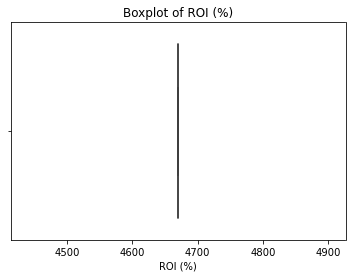

Outlier rows based on Z-scores:
Empty DataFrame
Columns: [genres, ROI (%)]
Index: []


C:\Users\USER PC\anaconda3\envs\learn-env\lib\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd


In [36]:
from scipy import stats
#Sample Data (Assuming the dataset is loaded into a DataFrame 'df')
data = {
    'genres': ['Cult Movies'],
    'ROI (%)': [4670.004578]
}

df = pd.DataFrame(data)

# Boxplot to visualize outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['ROI (%)'])
plt.title('Boxplot of ROI (%)')
plt.xlabel('ROI (%)')
plt.show()

# Calculate Z-scores to identify potential outliers
z_scores = np.abs(stats.zscore(df[['ROI (%)']]))

# Set a threshold for outliers (commonly used threshold is 3)
outliers = (z_scores > 3)

# Display rows with outliers
outlier_rows = df[outliers.any(axis=1)]
print("Outlier rows based on Z-scores:")
print(outlier_rows)

#### *Interpretation*
The output suggests that there are no outliers in the provided dataset based on the Z-score analysis

The empty DataFrame for Outliers: The result shows an empty DataFrame, which means that no rows in the ROI (%) column have a Z-score greater than the threshold (3 or -3). This implies that, according to the Z-score method, the ROI (%) value of 4670.004578 does not deviate significantly from the mean to be considered an outlier.

#### *Handling Null Values*
We will progress to drop Null Values and thereafter use another code to confirm that the Null values were actually dropped.

In [37]:
# Step 1: Drop rows with NULLs in important columns
exploded_table = exploded_table.dropna(subset=['genres', 'movie', 'ROI (%)'])
exploded_table

,genres,movie,ROI (%)
0,Action & Adventure,avatar,553.0
0,Comedy,avatar,553.0
0,Mystery & Suspense,avatar,553.0
0,Science Fiction & Fantasy,avatar,553.0
1,Action & Adventure,pirates of the caribbean: on stranger tides,155.0
...,...,...,...
6223,Mystery & Suspense,following,3908.0
6226,Comedy,my date with drew,16358.0
6226,Documentary,my date with drew,16358.0
6226,Special Interest,my date with drew,16358.0


In [38]:
# Check if there are any null values in the 'genres', 'movie', or 'ROI (%)' columns after dropping rows
null_counts = exploded_table[['genres', 'movie', 'ROI (%)']].isnull().sum()

# Print the null counts for each column
print(null_counts)


genres     0
movie      0
ROI (%)    0
dtype: int64


#### *Calculationg Average ROI as per the Genre*


We will group the data by 'Genres' and calculate the average ROI for each genre, then sort then in a descending order. This helps us understand how different genres performed financially.

The relevant codes is outlined in the next code of cells.


In [39]:
#  Group by 'genres' and calculate average ROI
grouped_table = exploded_table.groupby('genres')['ROI (%)'].mean().reset_index()
grouped_table.head()

,genres,ROI (%)
0,Action & Adventure,281.021448
1,Animation,527.445783
2,Anime & Manga,53.000000
3,Art House & International,481.818966
4,Classics,839.873684


In [40]:
#Sort by ROI in descending order
grouped_table = grouped_table.sort_values(by='ROI (%)', ascending=False)
grouped_table.head()


,genres,ROI (%)
6,Cult Movies,4669.958333
11,Horror,975.298217
17,Special Interest,932.209677
7,Documentary,868.586466
4,Classics,839.873684


In [41]:
# Reset index to clean it up
grouped_table = grouped_table.reset_index(drop=True)
grouped_table.head()

,genres,ROI (%)
0,Cult Movies,4669.958333
1,Horror,975.298217
2,Special Interest,932.209677
3,Documentary,868.586466
4,Classics,839.873684


#### *Data Visualization on the Relationship between Genre and Average ROI*

Understanding how different film genres perform in terms of Return on Investment (ROI) is crucial for data-driven decision-making in the entertainment industry. In this analysis, we calculate the Average ROI for each Genre and present the results using a bar graph for clarity.

We will thereafter normalize the data to 100% and plot the final bar graph.


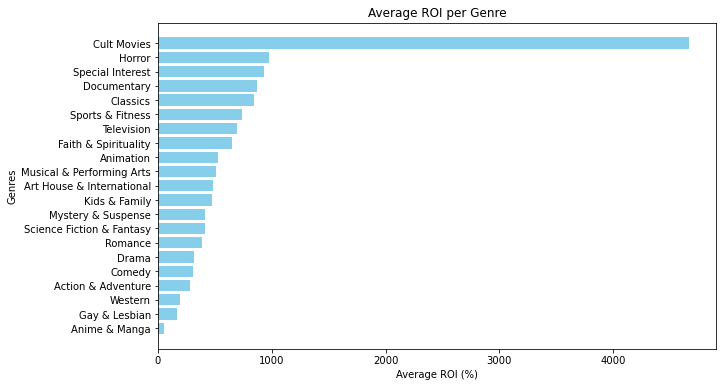

In [42]:
# Bar chart for average ROI per genre
plt.figure(figsize=(10,6))
plt.barh(grouped_table['genres'], grouped_table['ROI (%)'], color='skyblue')
plt.xlabel('Average ROI (%)')
plt.ylabel('Genres')
plt.title('Average ROI per Genre')
plt.gca().invert_yaxis()  # Invert y-axis to show highest ROI at the top
plt.show()

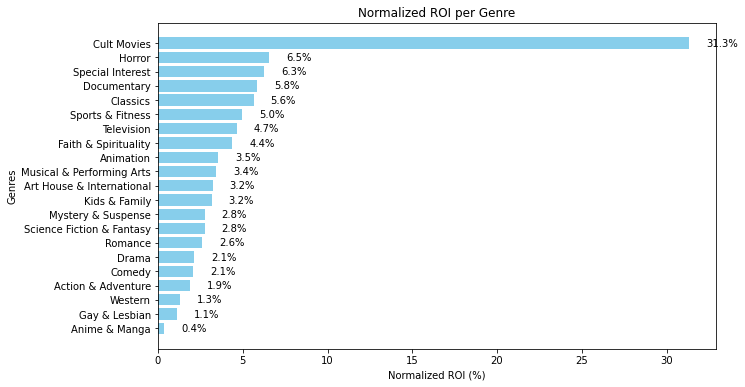

In [43]:
# Normalization and relevant Bar Graph
#Assuming 'grouped_table' contains the necessary data
total_roi = grouped_table['ROI (%)'].sum()

# Normalize the ROI values to ensure they sum to 100%
grouped_table['normalized_ROI'] = (grouped_table['ROI (%)'] / total_roi) * 100

# Ensure the normalized values sum exactly to 100 by adjusting based on total
normalized_total = grouped_table['normalized_ROI'].sum()
adjustment_factor = 100 / normalized_total

# Re-adjust the normalized ROIs to ensure they sum exactly to 100
grouped_table['normalized_ROI'] = grouped_table['normalized_ROI'] * adjustment_factor

# Check if the sum of normalized ROIs is 100
assert abs(grouped_table['normalized_ROI'].sum() - 100) < 1e-2, "The normalized ROIs don't sum to 100!"

# Plot the normalized ROI percentages
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart for the normalized ROI percentages
plt.barh(grouped_table['genres'], grouped_table['normalized_ROI'], color='skyblue')

# Add labels and title
plt.xlabel('Normalized ROI (%)')
plt.ylabel('Genres')
plt.title('Normalized ROI per Genre')

# Invert y-axis to show highest ROI at the top
plt.gca().invert_yaxis()

# Annotate each bar with its normalized percentage value
for index, value in enumerate(grouped_table['normalized_ROI']):
    plt.text(value + 1, index, f'{value:.1f}%', va='center', ha='left', fontsize=10, color='black')

# Show the plot
plt.show()

#### *Genre Perfomance based on ROI Results*
'Cult Movies' significantly outperform all other genres, with an average ROI of over 4600%. This suggests that niche, fan-favorite films can be extremely profitable despite often having lower budgets.

'Horror, Special Interest, and Documentary genres' also demonstrate strong returns, all averaging over 800%, which aligns with industry trends showing that lower-budget films in these genres often achieve high box office results.

Classics, though generally older, still maintain a high ROI, possibly due to re-releases, loyal fan bases, and minimal additional production costs.

#### *Conclusion*
The data suggests that investors and studios looking for high ROI should explore opportunities in Cult, Horror, and Documentary genres. These genres combine lower production costs with high audience engagement, creating a favorable financial outcome.


##### Chris
Same as before do not touch anything outside of these cells add as many cells as you would like between here and the next name. Do not edit anythin in the document if you need to edit anything write it down and tell me about it later

##### Vihaan
Same as before do not touch anything outside of these cells add as many cells as you would like between here and the next name. Do not edit anythin in the document if you need to edit anything write it down and tell me about it later

#### *2. Hypothesis Testing*  

## 【4】**Business Recommendations**  

## 【5】**Limitations of Our Analysis**  